# a1 - Retention metrics, precisely
learn-customer-retention-with-phoebe - by Phoebe Fu

This notebook computes day-N retention three ways on the game telemetry data and shows why the
course reports ONLY forward-looking classic retention with frozen history.

- **classic D-N**: came back exactly on day N after install
- **rolling D-N**: came back on day N **or later** (banned for reporting: history restates)
- **bracket W1**: came back at least once within days 1-7 (each bracket independent)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Resolve repo root whether the kernel starts in the repo root or in notebooks/
ROOT = Path.cwd()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent
assert (ROOT / "data").exists(), "run this notebook from the repo root or notebooks/"
np.random.seed(42)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

game = pd.read_csv(ROOT / "data" / "game_telemetry.csv",
                   parse_dates=["install_date", "activity_date"])
game["day"] = (game["activity_date"] - game["install_date"]).dt.days
base = game["user_id"].nunique()
print(f"{len(game):,} activity rows, {base:,} players")
game.head()

31,368 activity rows, 8,000 players


,user_id,install_date,activity_date,sessions,day
0,P00074,2026-06-01,2026-06-01,4,0
1,P00114,2026-06-01,2026-06-01,1,0
2,P00127,2026-06-01,2026-06-01,3,0
3,P00152,2026-06-01,2026-06-01,4,0
4,P00156,2026-06-01,2026-06-01,5,0


## The three counting variants

Same events, one denominator (all installs), three different "D7" numbers. Classic counts a
return on exactly day N. Rolling counts day N or any later day, so a dormant player returning on
day 29 retroactively lifts D7 for a cohort you already reported. Bracket counts any return inside
a window, useful for products with a natural repurchase interval.

In [2]:
def classic(n):
    return game.loc[game["day"] == n, "user_id"].nunique() / base

def rolling(n):
    return game.loc[game["day"] >= n, "user_id"].nunique() / base

def bracket(lo, hi):
    return game.loc[game["day"].between(lo, hi), "user_id"].nunique() / base

classic_vals = {n: classic(n) for n in (1, 7, 14, 30)}
d7_variants = {"classic D7 (day == 7)": classic(7),
               "rolling D7 (day >= 7)": rolling(7),
               "bracket W1 (days 1-7)": bracket(1, 7)}

table = pd.DataFrame({
    "metric": ["classic D1", "classic D7", "classic D14", "classic D30",
               "rolling D7", "bracket W1"],
    "value": [classic_vals[1], classic_vals[7], classic_vals[14], classic_vals[30],
              rolling(7), bracket(1, 7)]})
table["value"] = (table["value"] * 100).round(1)
table

,metric,value
0,classic D1,27.900
1,classic D7,13.600
2,classic D14,9.100
3,classic D30,6.900
4,rolling D7,69.900
5,bracket W1,62.300


In [3]:
# Assert classic values match the generator ground truth within 0.2 percentage points
GROUND_TRUTH = {1: 27.9, 7: 13.6, 14: 9.1, 30: 6.9}
for n, gt in GROUND_TRUTH.items():
    got = classic_vals[n] * 100
    assert abs(got - gt) <= 0.2, f"classic D{n}: got {got:.2f}, expected {gt} +/- 0.2"
    print(f"classic D{n}: {got:.1f}% matches ground truth {gt}% (within 0.2 points)")

classic D1: 27.9% matches ground truth 27.9% (within 0.2 points)
classic D7: 13.6% matches ground truth 13.6% (within 0.2 points)
classic D14: 9.1% matches ground truth 9.1% (within 0.2 points)
classic D30: 6.9% matches ground truth 6.9% (within 0.2 points)


## Frozen-history demo

The course law: fix the cohort by its anchor date, look forward, and once the window closes the
number is immutable. Below is D7 for the players who installed on 2026-06-05. Their day-7 window
closed on 2026-06-12. No event that happens after that date can change this number, which is what
makes it safe to put in a report.

In [4]:
cohort_day = pd.Timestamp("2026-06-05")
cohort = game[game["install_date"] == cohort_day]
cohort_size = cohort["user_id"].nunique()
d7_cohort = cohort.loc[cohort["day"] == 7, "user_id"].nunique() / cohort_size
print(f"Install cohort {cohort_day.date()}: {cohort_size} players")
print(f"Classic D7 = {d7_cohort:.1%}  (window closed {cohort_day.date() + pd.Timedelta(days=7)}, immutable)")

Install cohort 2026-06-05: 135 players
Classic D7 = 13.3%  (window closed 2026-06-12, immutable)


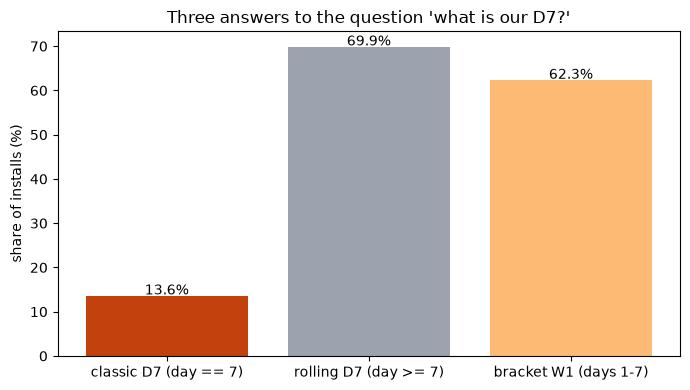

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(d7_variants.keys())
vals = [d7_variants[k] * 100 for k in names]
bars = ax.bar(names, vals, color=["#C2410C", "#9CA3AF", "#FDBA74"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}%", ha="center")
ax.set_ylabel("share of installs (%)")
ax.set_title("Three answers to the question 'what is our D7?'")
plt.tight_layout()
plt.show()

**Takeaway**: the three variants disagree by design, not by error. The course reports classic
(forward-looking, frozen) numbers only; rolling and bracket are taught as concepts with a
"never for reporting" warning, because their history restates as time passes.